In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dishadevgirkar26","key":"77475710e94ba51d6b83f62c4358dc72"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s leapgestrecog

ref                                                                title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
gti-upm/leapgestrecog                                              Hand Gesture Recognition Database                 2286085038  2018-07-30 06:43:29.133000          42702        690  0.75             
ryanbijujoseph/hand-gesture-dataset                                hand gesture dataset                               988046106  2026-04-25 21:25:25.860000             23          0  0.5625           
mrayyanshehzad/ryn-hgd-webcam-hand-gesture-dataset-grayscale       RYN-HGD: Webcam Hand Gesture Dataset (Grayscale)    77267077  2025-12-30 15:55:44.833000             72          0  0.8125       

In [ ]:
!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:13<00:00, 163MB/s]



In [ ]:
!unzip -q leapgestrecog.zip

replace leapGestRecog/00/01_palm/frame_00_01_0001.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

print(os.listdir("leapGestRecog")[:5])

['06', '07', '00', '02', '08']


In [ ]:
!pip install tensorflow opencv-python

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [ ]:
dataset_path = "leapGestRecog"

images = []
labels = []

IMG_SIZE = 64

In [ ]:
count = 0
MAX_IMAGES = 5000

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    for gesture in os.listdir(person_path):

        gesture_path = os.path.join(person_path, gesture)

        for img_name in os.listdir(gesture_path):

            img_path = os.path.join(
                gesture_path,
                img_name
            )

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            img = cv2.resize(
                img,
                (IMG_SIZE, IMG_SIZE)
            )

            images.append(img)
            labels.append(gesture)

            count += 1

            if count >= MAX_IMAGES:
                break

        if count >= MAX_IMAGES:
            break

    if count >= MAX_IMAGES:
        break

print("Loaded:", len(images))

Loaded: 5000


In [ ]:
X = np.array(images)

X = X / 255.0

X = X.reshape(
    X.shape[0],
    IMG_SIZE,
    IMG_SIZE,
    1
)

In [ ]:
X = np.array(images)

X = X / 255.0

X = X.reshape(
    X.shape[0],
    IMG_SIZE,
    IMG_SIZE,
    1
)

In [ ]:
encoder = LabelEncoder()

y = encoder.fit_transform(labels)

y = to_categorical(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,1)
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        y.shape[1],
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 170ms/step - accuracy: 0.8213 - loss: 0.5568 - val_accuracy: 0.9850 - val_loss: 0.0504
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - accuracy: 0.9890 - loss: 0.0428 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.9905 - loss: 0.0276 - val_accuracy: 0.9990 - val_loss: 0.0058
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 177ms/step - accuracy: 0.9987 - loss: 0.0091 - val_accuracy: 1.0000 - val_loss: 2.4886e-04
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - accuracy: 0.9985 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 3.5735e-04
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.9987 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 1.0789e-04
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 174ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 4.7667e-05
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9990 - loss: 0.0047
Accuracy: 0.9990000128746033


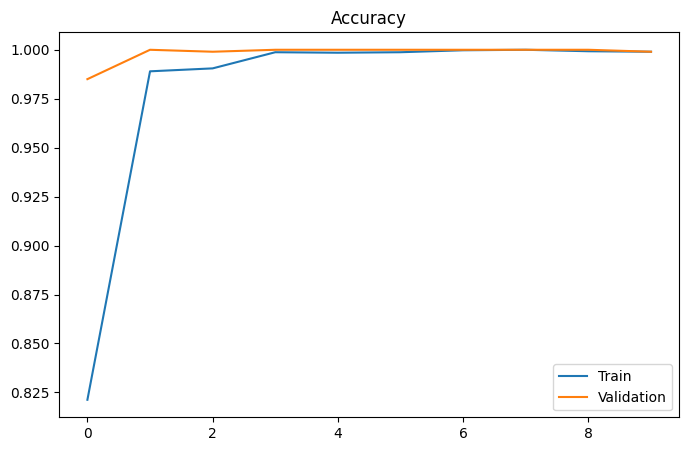

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend([
    "Train",
    "Validation"
])

plt.title("Accuracy")

plt.show()

In [ ]:
model.save("gesture_model.h5")

In [ ]:
MAX_IMAGES = 10000